In [31]:
#Google drive mount
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
#Chek GPP-for model train
import torch

gpu_available = torch.cuda.is_available()
gpu_name = torch.cuda.get_device_name(0) if gpu_available else "No GPU available"

print("GPU available:", gpu_available)
print("GPU name:", gpu_name)

if not gpu_available:
    print("For model training later, enable GPU from Runtime > Change runtime type > T4 GPU.")

GPU available: True
GPU name: Tesla T4


In [33]:
#Create google drive project folders
import os

drive_base = "/content/drive/MyDrive/USW_Dissertation/PromptInjectionDetectionSystem"

drive_folders = [
    "github_repo_backup",
    "data/raw",
    "data/processed",
    "notebooks",
    "results/figures",
    "results/tables",
    "models/distilbert",
    "models/roberta",
    "models/secbert",
    "shap_outputs",
    "screenshots",
    "dissertation_evidence"
]

for folder in drive_folders:
    os.makedirs(os.path.join(drive_base, folder), exist_ok=True)

print("Google Drive project folders are ready.")
print("Drive base path:", drive_base)

Google Drive project folders are ready.
Drive base path: /content/drive/MyDrive/USW_Dissertation/PromptInjectionDetectionSystem


In [34]:
#Clone GitHub-data-analysis branch
%cd /content

!rm -rf PromptInjectionDetectionSystem

!git clone -b data-analysis https://github.com/Al-Amin95/PromptInjectionDetectionSystem.git

%cd /content/PromptInjectionDetectionSystem

print("Current working directory:")
!pwd

print("\nCurrent Git branch:")
!git branch

print("\nRepository files:")
!ls

/content
Cloning into 'PromptInjectionDetectionSystem'...
remote: Enumerating objects: 35, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 35 (delta 9), reused 20 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (35/35), 128.55 KiB | 5.14 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/PromptInjectionDetectionSystem
Current working directory:
/content/PromptInjectionDetectionSystem

Current Git branch:
* data-analysis

Repository files:
data  models	 README.md	   results	src
docs  notebooks  requirements.txt  screenshots	webapp


In [35]:
#Install required libraries
!pip install -q -r requirements.txt

print("Required libraries installed successfully.")

Required libraries installed successfully.


In [36]:
#Check python libraries
import sys
import pandas as pd
import numpy as np
import pyarrow
import sklearn
import matplotlib
import seaborn as sns
import torch

print("Python version:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("pyarrow:", pyarrow.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("torch:", torch.__version__)

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
pandas: 2.2.2
numpy: 2.0.2
pyarrow: 18.1.0
scikit-learn: 1.6.1
matplotlib: 3.10.0
seaborn: 0.13.2
torch: 2.11.0+cu128


In [37]:
#Check project folder structure
import os

required_folders = [
    "data/raw",
    "data/processed",
    "docs",
    "models",
    "notebooks",
    "results",
    "results/figures",
    "results/tables",
    "screenshots",
    "src",
    "webapp"
]

print("Project folder structure check:\n")

for folder in required_folders:
    print(f"{folder}: {os.path.exists(folder)}")

Project folder structure check:

data/raw: True
data/processed: True
docs: True
models: True
notebooks: True
results: True
results/figures: True
results/tables: True
screenshots: True
src: True
webapp: True


In [38]:
#Check raw dataset files
train_path = "data/raw/train-00000-of-00001-9564e8b05b4757ab.parquet"
test_path = "data/raw/test-00000-of-00001-701d16158af87368.parquet"

print("Train file exists:", os.path.exists(train_path))
print("Test file exists:", os.path.exists(test_path))

print("\nFiles inside data/raw:")
!ls -lh data/raw

Train file exists: True
Test file exists: True

Files inside data/raw:
total 52K
-rw-r--r-- 1 root root 11K Jun 22 06:08 test-00000-of-00001-701d16158af87368.parquet
-rw-r--r-- 1 root root 40K Jun 22 06:08 train-00000-of-00001-9564e8b05b4757ab.parquet


In [39]:
#Test-read parquet dataset
import pandas as pd

train_df = pd.read_parquet(train_path)
test_df = pd.read_parquet(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("Train columns:", list(train_df.columns))
print("Test columns:", list(test_df.columns))

Train shape: (546, 2)
Test shape: (116, 2)
Train columns: ['text', 'label']
Test columns: ['text', 'label']


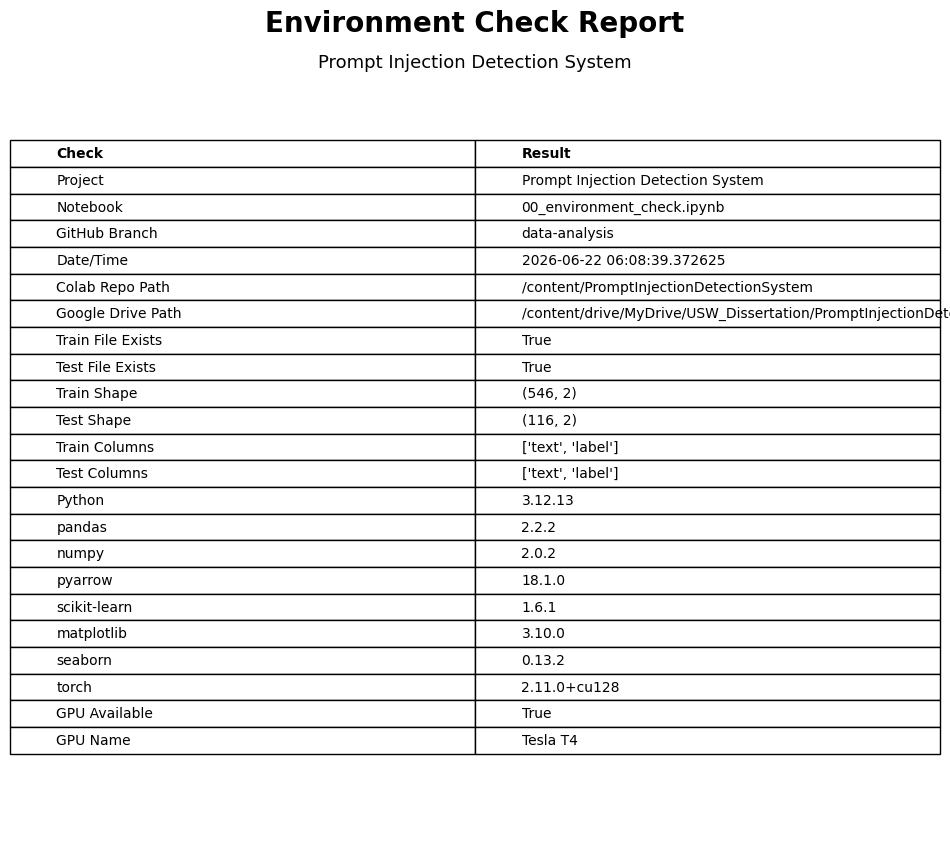

Environment report image saved in repo folder: results/figures/environment_check_report.png
Environment report image saved in Google Drive: /content/drive/MyDrive/USW_Dissertation/PromptInjectionDetectionSystem/results/figures/environment_check_report.png


In [40]:
#Create  environment report

import matplotlib.pyplot as plt
import os
from datetime import datetime
import torch
import pandas as pd
import numpy as np
import pyarrow
import sklearn
import matplotlib
import seaborn as sns
import sys

os.makedirs("results/figures", exist_ok=True)
os.makedirs(os.path.join(drive_base, "results/figures"), exist_ok=True)

report_data = [
    ["Project", "Prompt Injection Detection System"],
    ["Notebook", "00_environment_check.ipynb"],
    ["GitHub Branch", "data-analysis"],
    ["Date/Time", str(datetime.now())],
    ["Colab Repo Path", "/content/PromptInjectionDetectionSystem"],
    ["Google Drive Path", drive_base],
    ["Train File Exists", str(os.path.exists(train_path))],
    ["Test File Exists", str(os.path.exists(test_path))],
    ["Train Shape", str(train_df.shape)],
    ["Test Shape", str(test_df.shape)],
    ["Train Columns", str(list(train_df.columns))],
    ["Test Columns", str(list(test_df.columns))],
    ["Python", sys.version.split()[0]],
    ["pandas", pd.__version__],
    ["numpy", np.__version__],
    ["pyarrow", pyarrow.__version__],
    ["scikit-learn", sklearn.__version__],
    ["matplotlib", matplotlib.__version__],
    ["seaborn", sns.__version__],
    ["torch", torch.__version__],
    ["GPU Available", str(torch.cuda.is_available())],
    ["GPU Name", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU available"]
]

fig, ax = plt.subplots(figsize=(12, 10))
ax.axis("off")

ax.text(
    0.5,
    1.05,
    "Environment Check Report",
    fontsize=20,
    fontweight="bold",
    ha="center",
    va="center"
)

ax.text(
    0.5,
    1.00,
    "Prompt Injection Detection System",
    fontsize=13,
    ha="center",
    va="center"
)

table = ax.table(
    cellText=report_data,
    colLabels=["Check", "Result"],
    cellLoc="left",
    colLoc="left",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

for col in range(2):
    table[(0, col)].set_text_props(weight="bold")

repo_image_path = "results/figures/environment_check_report.png"
drive_image_path = os.path.join(drive_base, "results/figures/environment_check_report.png")

plt.savefig(repo_image_path, bbox_inches="tight", dpi=300)
plt.savefig(drive_image_path, bbox_inches="tight", dpi=300)

plt.show()

print("Environment report image saved in repo folder:", repo_image_path)
print("Environment report image saved in Google Drive:", drive_image_path)